# Task 2 – Exploratory Data Analysis (EDA) & Business Intelligence

## Customer Churn Analysis
**Internship:** ApexPlanet Software Pvt. Ltd.  
**Submitted by:** Rahul Kumar Ojha

### Objective
To uncover patterns, trends and relationships in customer data using descriptive statistics, visualizations and SQL business analysis, and to propose a dashboard design.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


In [3]:
df = pd.read_csv(r"C:\Users\rahul\Downloads\Customer_Churn_Cleaned.csv")

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.850000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,55.573529
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,54.075000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.905556
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,75.825000


## 1. Dataset Understanding

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()


Rows: 7043
Columns: 22
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7

In [5]:
display(df.describe())
display(df.describe(include="object"))


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,66.880842
std,0.368612,24.559481,30.090047,2265.270398,60.660378
min,0.000000,0.000000,18.250000,18.800000,13.775000
25%,0.000000,9.000000,35.500000,402.225000,36.255000
50%,0.000000,29.000000,70.350000,1397.475000,70.450000
75%,0.000000,55.000000,89.850000,3786.600000,90.285826
max,1.000000,72.000000,118.750000,8684.800000,1397.475000


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [6]:
print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("Missing Values"))
print("Duplicate rows:", df.duplicated().sum())


Missing values:


,Missing Values
customerID,0
gender,0
Churn,0
TotalCharges,0
MonthlyCharges,0
PaymentMethod,0
PaperlessBilling,0
Contract,0
StreamingMovies,0
StreamingTV,0


Duplicate rows: 0


In [7]:
df["SeniorCitizenLabel"] = df["SeniorCitizen"].map({0:"No",1:"Yes"})
df["ChurnFlag"] = df["Churn"].map({"Yes":1,"No":0})


## 2. Univariate Analysis

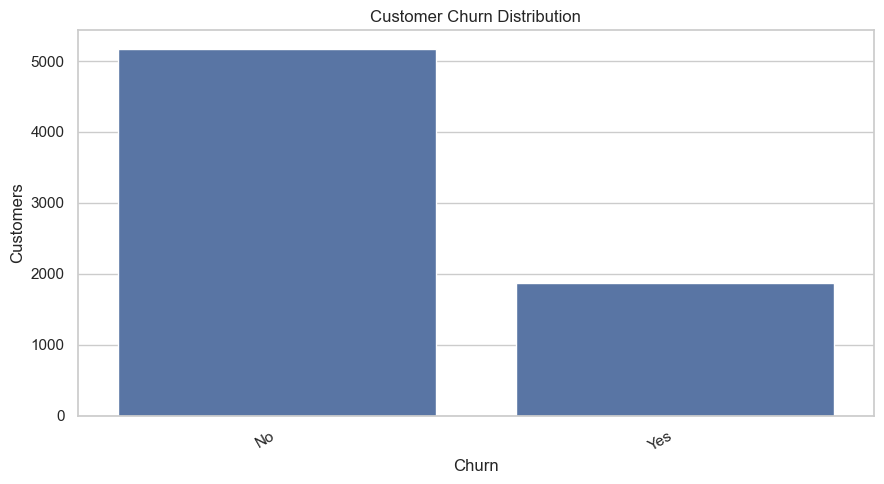

In [8]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Churn", order=df["Churn"].value_counts().index)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


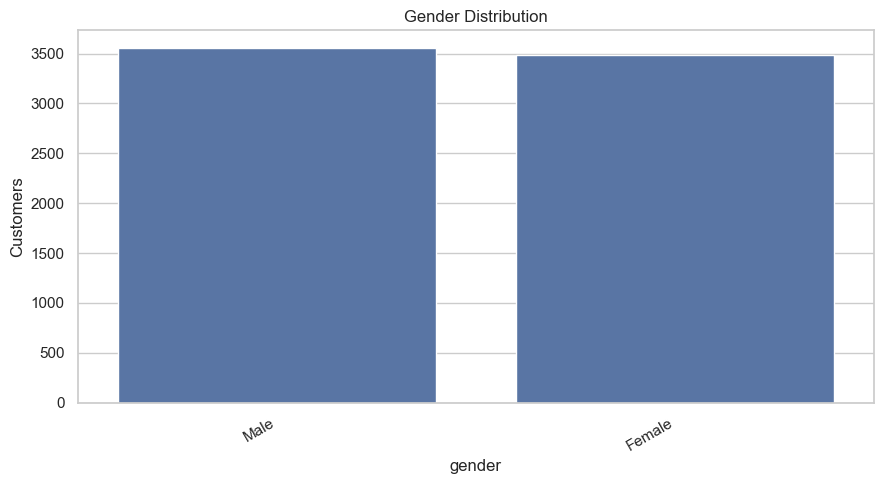

In [9]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="gender", order=df["gender"].value_counts().index)
plt.title("Gender Distribution")
plt.xlabel("gender")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


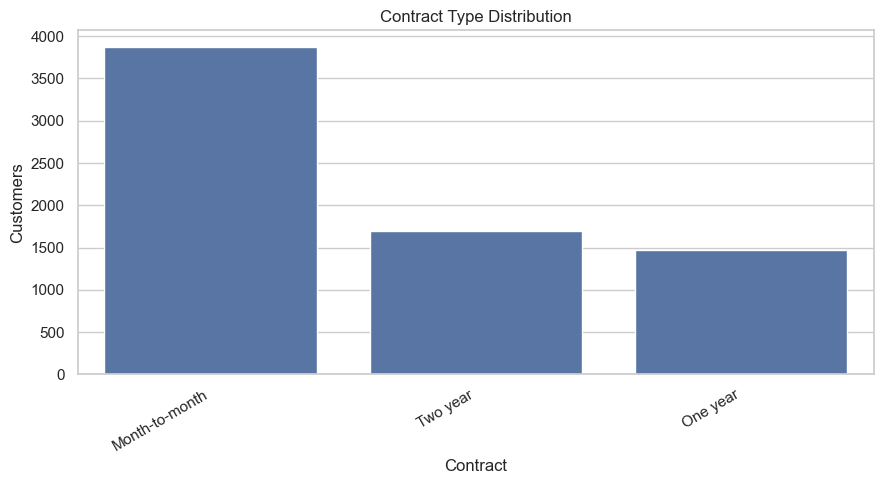

In [10]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Contract", order=df["Contract"].value_counts().index)
plt.title("Contract Type Distribution")
plt.xlabel("Contract")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


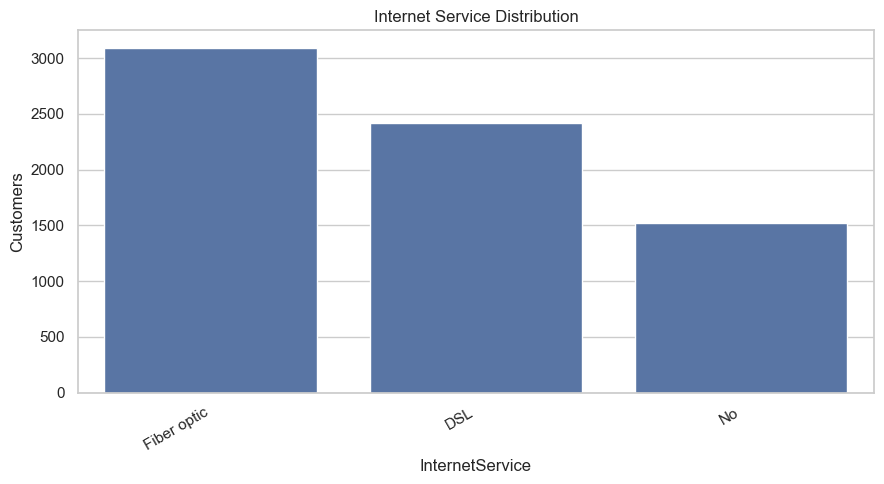

In [11]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="InternetService", order=df["InternetService"].value_counts().index)
plt.title("Internet Service Distribution")
plt.xlabel("InternetService")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


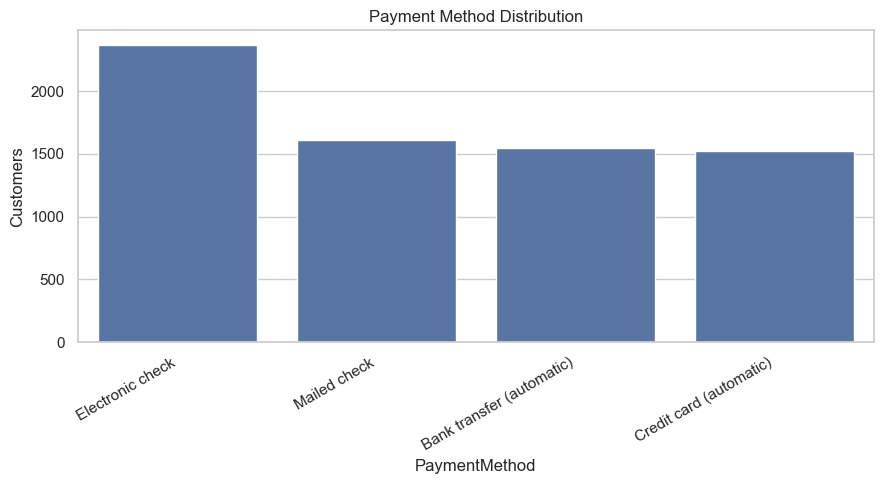

In [12]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="PaymentMethod", order=df["PaymentMethod"].value_counts().index)
plt.title("Payment Method Distribution")
plt.xlabel("PaymentMethod")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


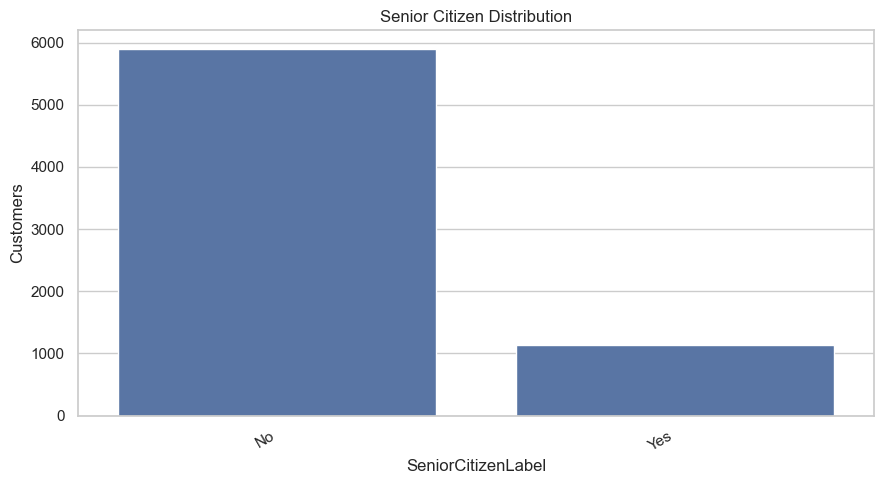

In [13]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="SeniorCitizenLabel", order=df["SeniorCitizenLabel"].value_counts().index)
plt.title("Senior Citizen Distribution")
plt.xlabel("SeniorCitizenLabel")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


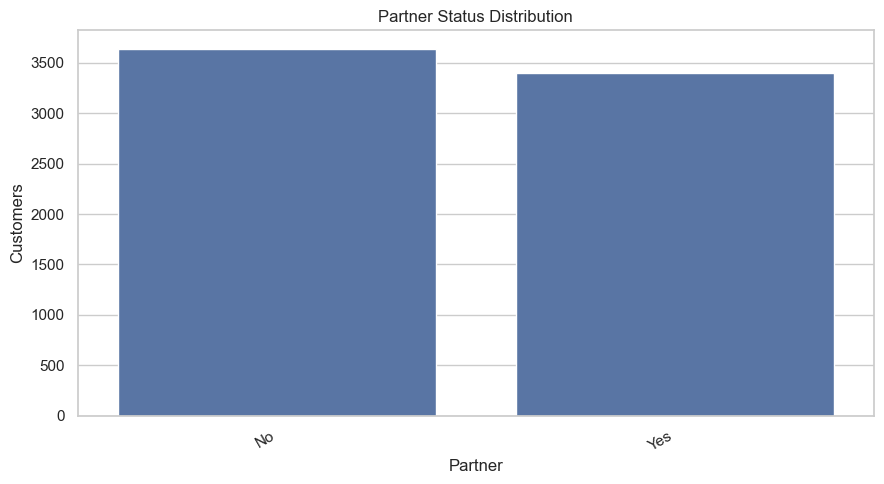

In [14]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Partner", order=df["Partner"].value_counts().index)
plt.title("Partner Status Distribution")
plt.xlabel("Partner")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


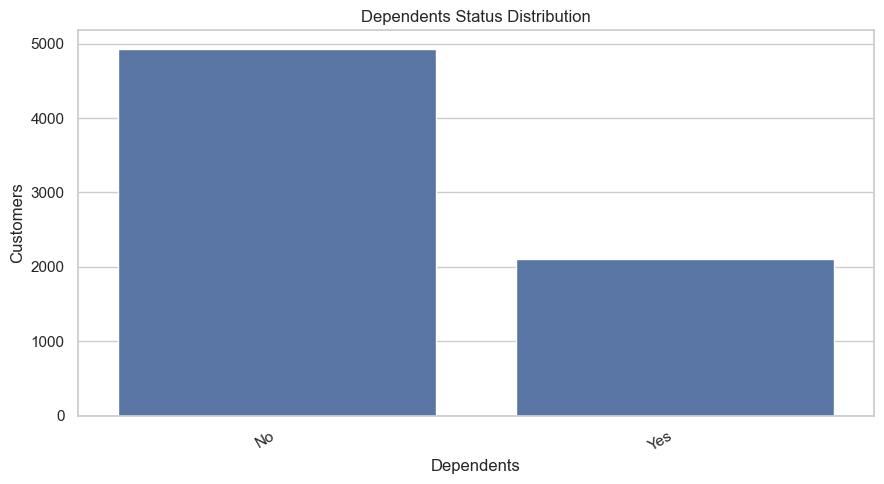

In [15]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Dependents", order=df["Dependents"].value_counts().index)
plt.title("Dependents Status Distribution")
plt.xlabel("Dependents")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


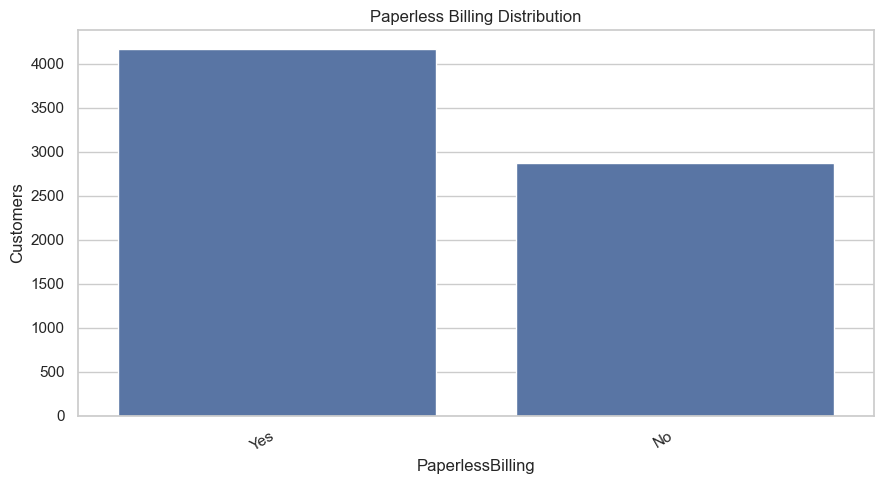

In [16]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="PaperlessBilling", order=df["PaperlessBilling"].value_counts().index)
plt.title("Paperless Billing Distribution")
plt.xlabel("PaperlessBilling")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


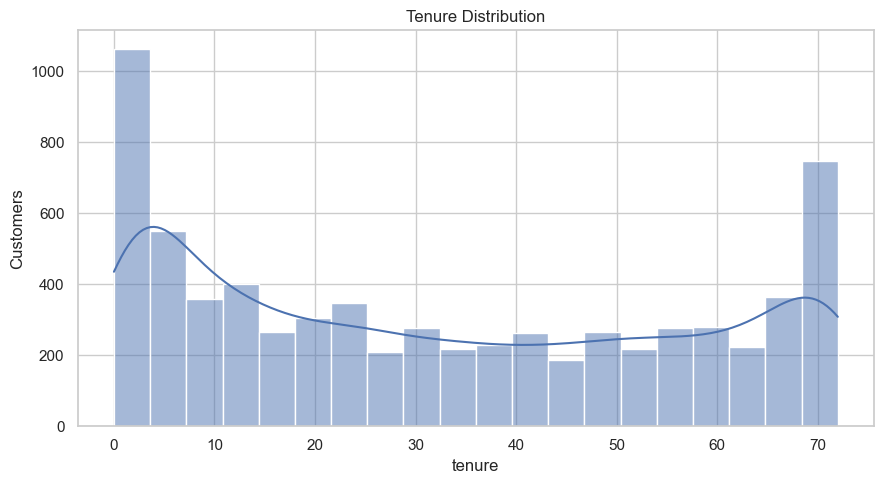

In [17]:
plt.figure(figsize=(9,5))
sns.histplot(df["tenure"], bins=20, kde=True)
plt.title("Tenure Distribution")
plt.xlabel("tenure")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()


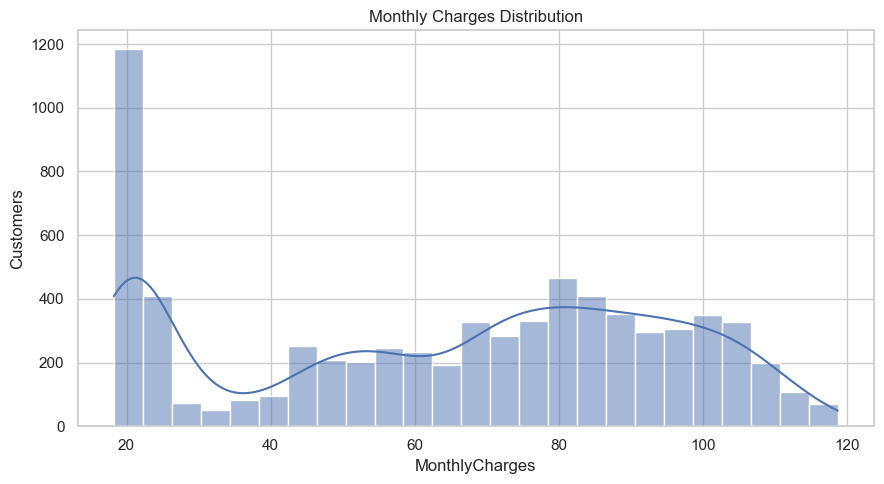

In [18]:
plt.figure(figsize=(9,5))
sns.histplot(df["MonthlyCharges"], bins=25, kde=True)
plt.title("Monthly Charges Distribution")
plt.xlabel("MonthlyCharges")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()


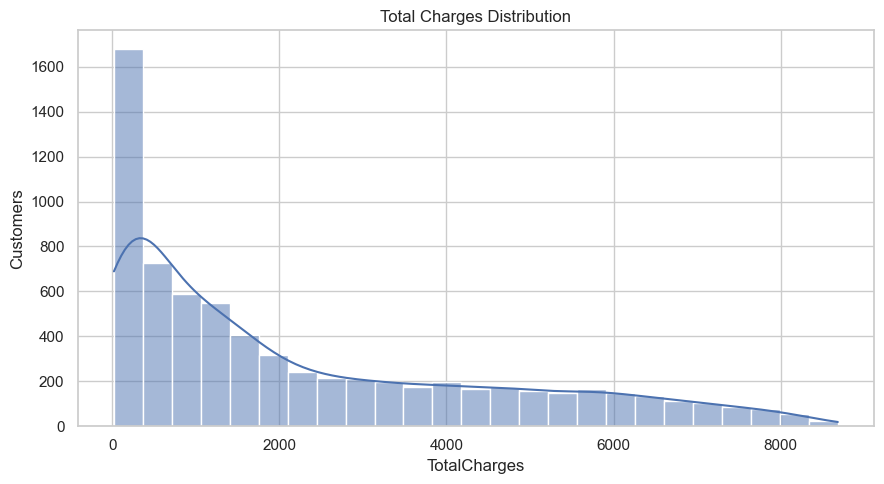

In [19]:
plt.figure(figsize=(9,5))
sns.histplot(df["TotalCharges"], bins=25, kde=True)
plt.title("Total Charges Distribution")
plt.xlabel("TotalCharges")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()


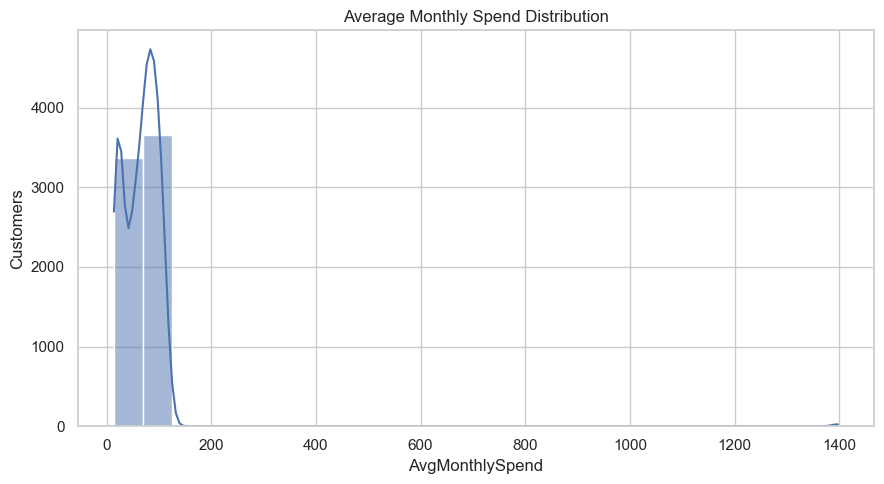

In [20]:
plt.figure(figsize=(9,5))
sns.histplot(df["AvgMonthlySpend"], bins=25, kde=True)
plt.title("Average Monthly Spend Distribution")
plt.xlabel("AvgMonthlySpend")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()


## 3. Bivariate Churn Analysis

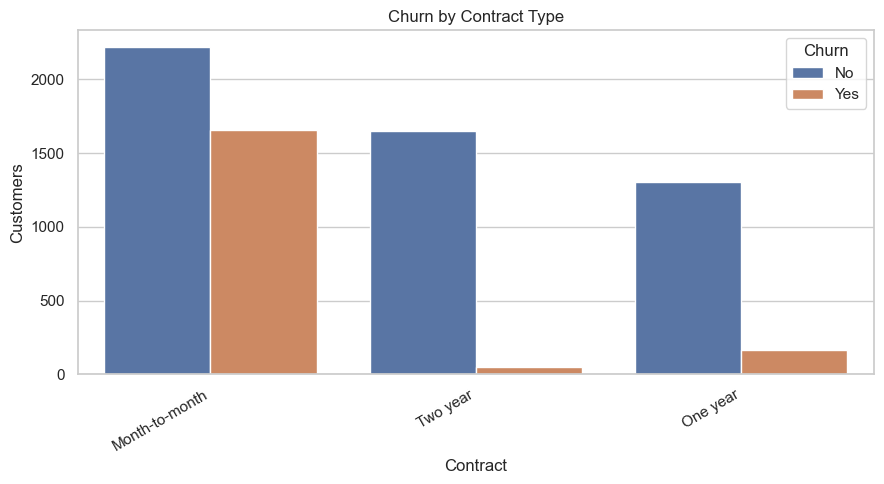

In [21]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Contract", hue="Churn", order=df["Contract"].value_counts().index)
plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


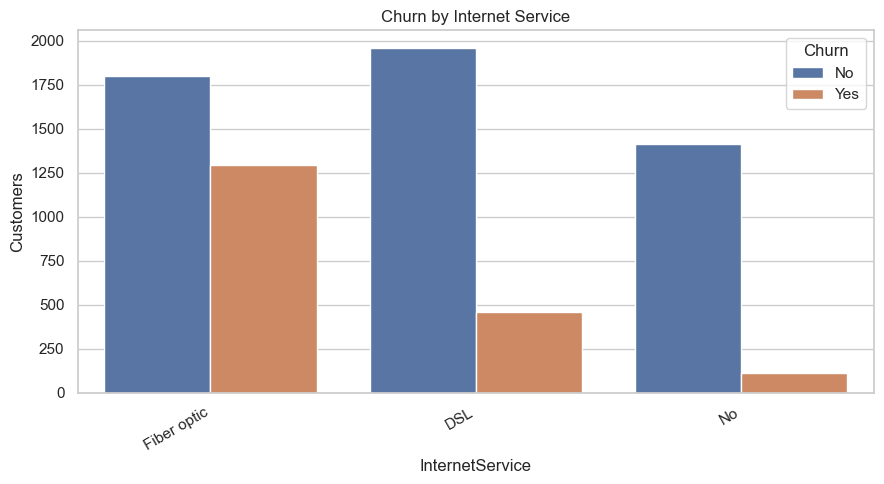

In [22]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="InternetService", hue="Churn", order=df["InternetService"].value_counts().index)
plt.title("Churn by Internet Service")
plt.xlabel("InternetService")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


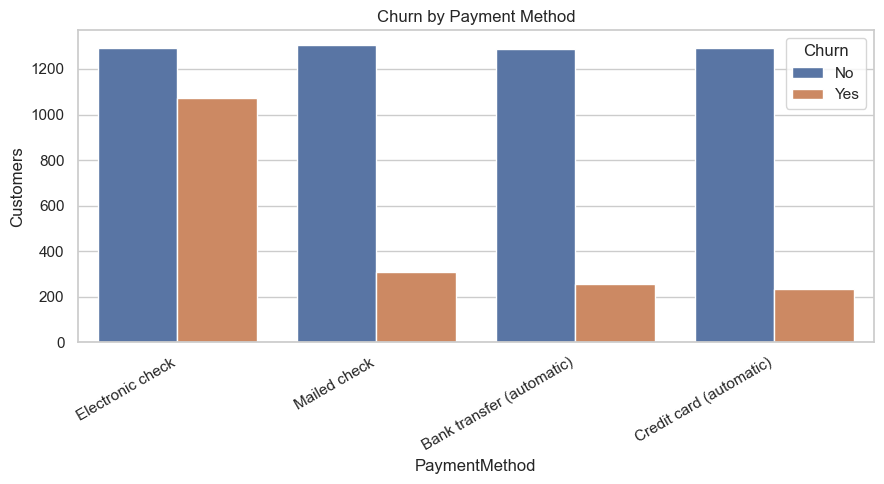

In [23]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn", order=df["PaymentMethod"].value_counts().index)
plt.title("Churn by Payment Method")
plt.xlabel("PaymentMethod")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


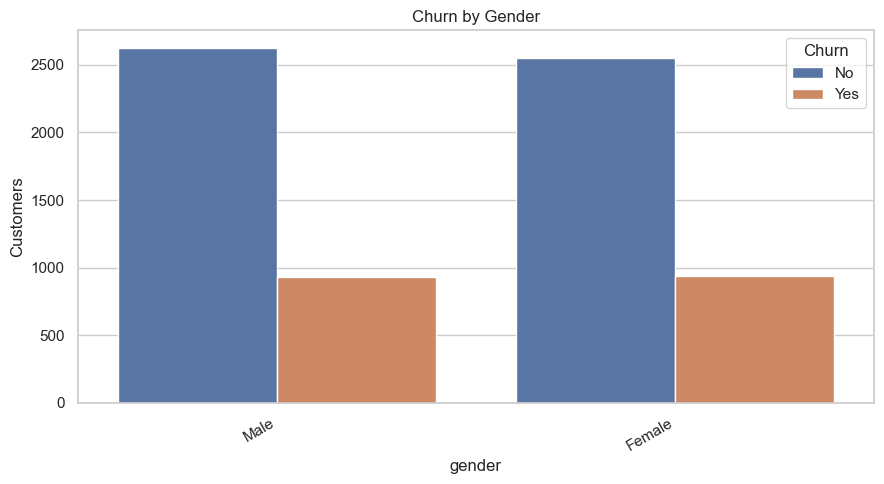

In [24]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="gender", hue="Churn", order=df["gender"].value_counts().index)
plt.title("Churn by Gender")
plt.xlabel("gender")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


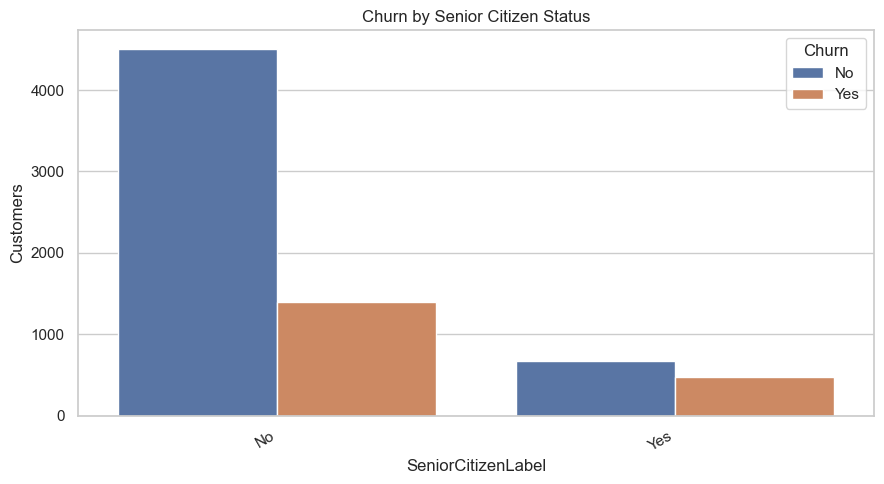

In [25]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="SeniorCitizenLabel", hue="Churn", order=df["SeniorCitizenLabel"].value_counts().index)
plt.title("Churn by Senior Citizen Status")
plt.xlabel("SeniorCitizenLabel")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


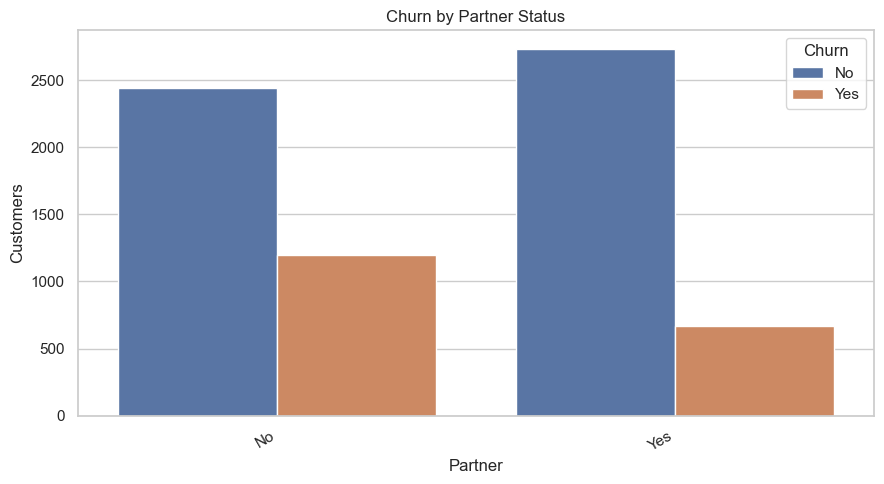

In [26]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Partner", hue="Churn", order=df["Partner"].value_counts().index)
plt.title("Churn by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


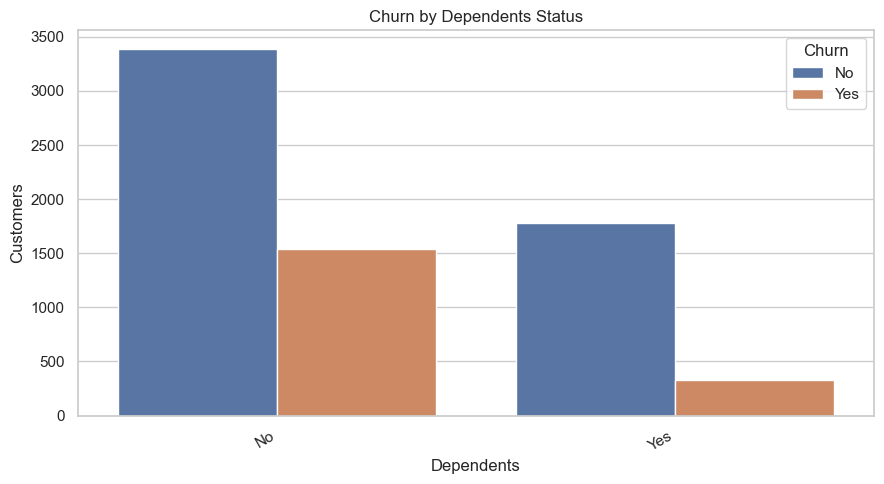

In [27]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Dependents", hue="Churn", order=df["Dependents"].value_counts().index)
plt.title("Churn by Dependents Status")
plt.xlabel("Dependents")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


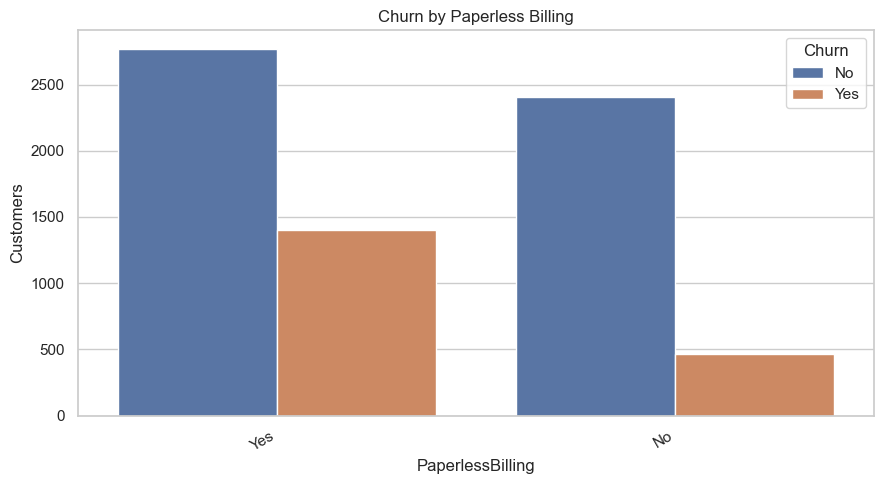

In [28]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="PaperlessBilling", hue="Churn", order=df["PaperlessBilling"].value_counts().index)
plt.title("Churn by Paperless Billing")
plt.xlabel("PaperlessBilling")
plt.ylabel("Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


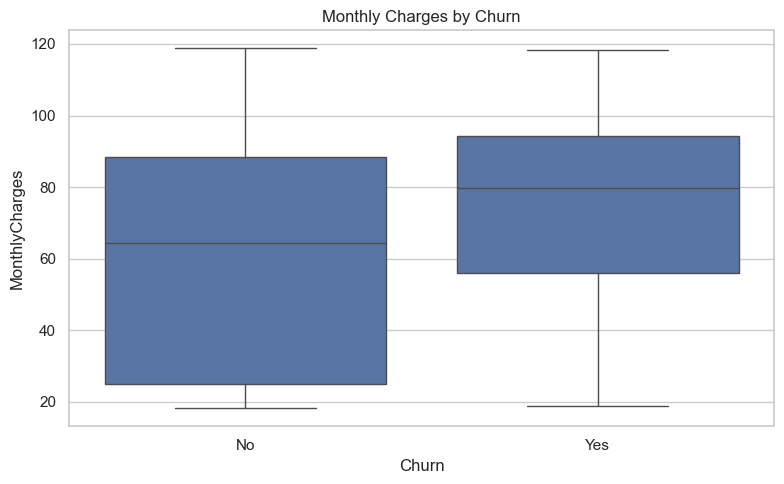

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.tight_layout()
plt.show()


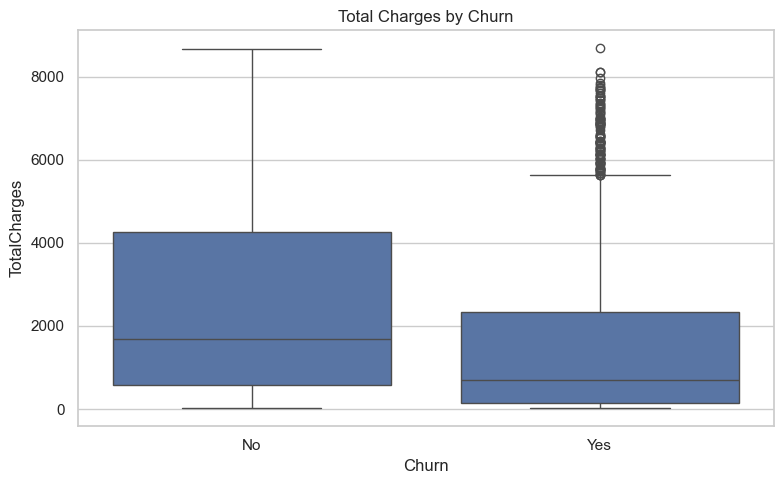

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges by Churn")
plt.tight_layout()
plt.show()


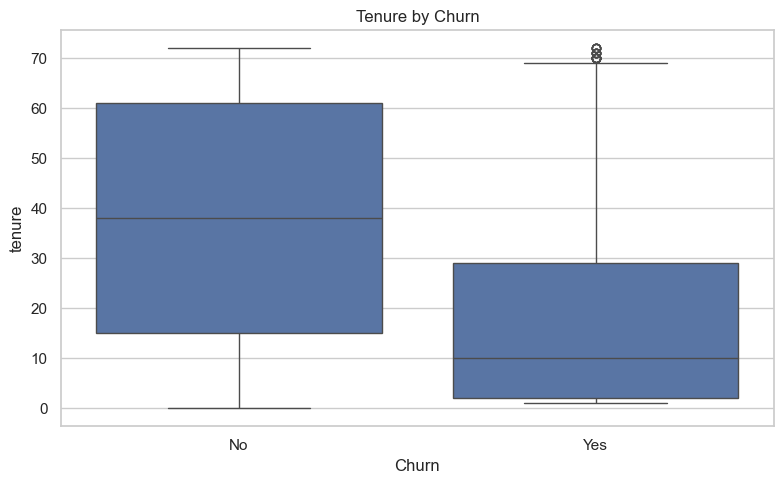

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure by Churn")
plt.tight_layout()
plt.show()


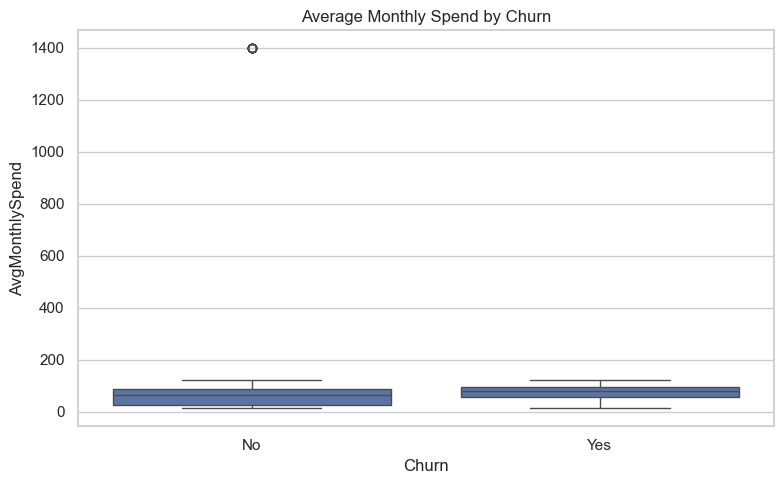

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="AvgMonthlySpend")
plt.title("Average Monthly Spend by Churn")
plt.tight_layout()
plt.show()


## 4. Churn Rate Analysis

In [33]:
churn_summary = df.groupby("Churn").size().reset_index(name="Customers")
churn_summary["Percentage"] = churn_summary["Customers"] / len(df) * 100
churn_summary


,Churn,Customers,Percentage
0,No,5174,73.463013
1,Yes,1869,26.536987


In [34]:
contract_churn = df.groupby("Contract")["ChurnFlag"].mean().mul(100).sort_values(ascending=False)
display(contract_churn.to_frame("Churn Rate (%)"))


,Churn Rate (%)
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


In [35]:
internet_churn = df.groupby("InternetService")["ChurnFlag"].mean().mul(100).sort_values(ascending=False)
display(internet_churn.to_frame("Churn Rate (%)"))


,Churn Rate (%)
InternetService,
Fiber optic,41.892765
DSL,18.959108
No,7.404980


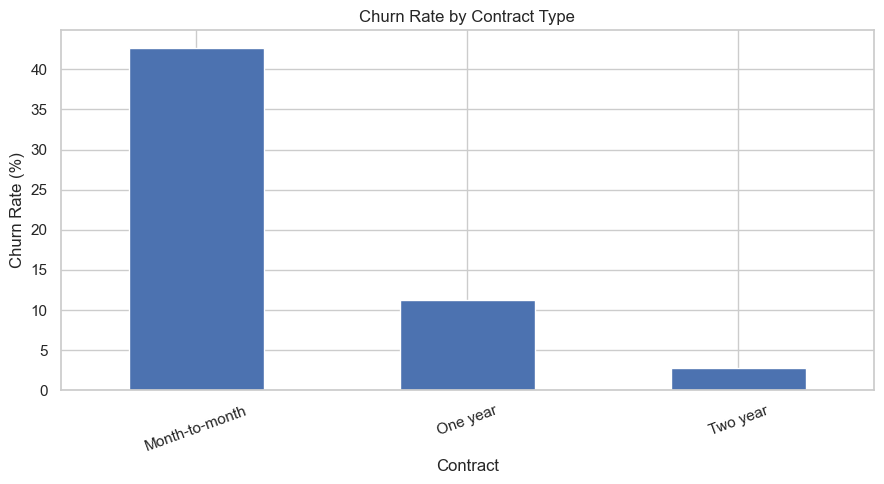

In [36]:
plt.figure(figsize=(9,5))
contract_churn.plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


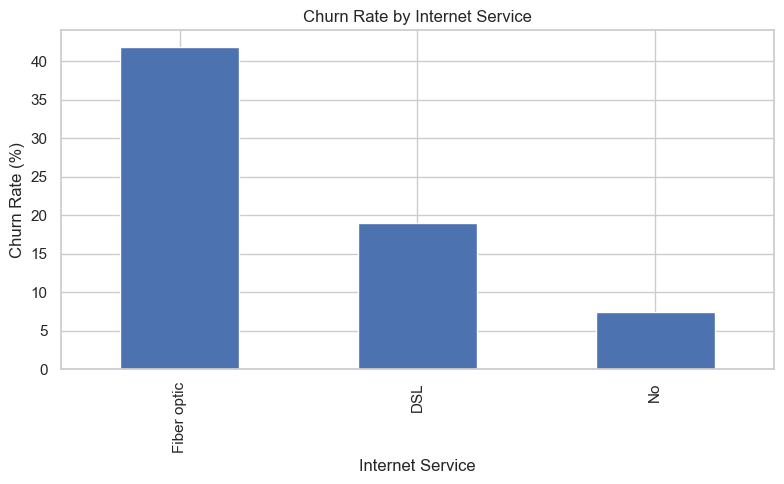

In [37]:
plt.figure(figsize=(8,5))
internet_churn.plot(kind="bar")
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Internet Service")
plt.tight_layout()
plt.show()


## 5. Multivariate Analysis & Correlation

In [38]:
numeric_cols = ["tenure","MonthlyCharges","TotalCharges","AvgMonthlySpend","ChurnFlag"]
correlation = df[numeric_cols].corr()
display(correlation)


,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,ChurnFlag
tenure,1.000000,0.247900,0.825464,0.077018,-0.352229
MonthlyCharges,0.247900,1.000000,0.650864,0.468284,0.193356
TotalCharges,0.825464,0.650864,1.000000,0.310219,-0.199037
AvgMonthlySpend,0.077018,0.468284,0.310219,1.000000,0.074834
ChurnFlag,-0.352229,0.193356,-0.199037,0.074834,1.000000


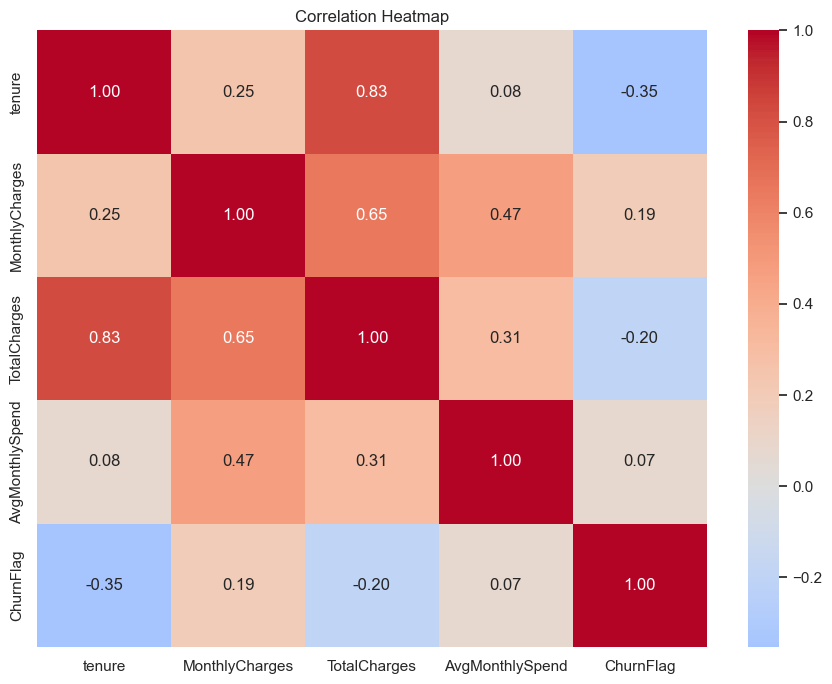

In [39]:
plt.figure(figsize=(9,7))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


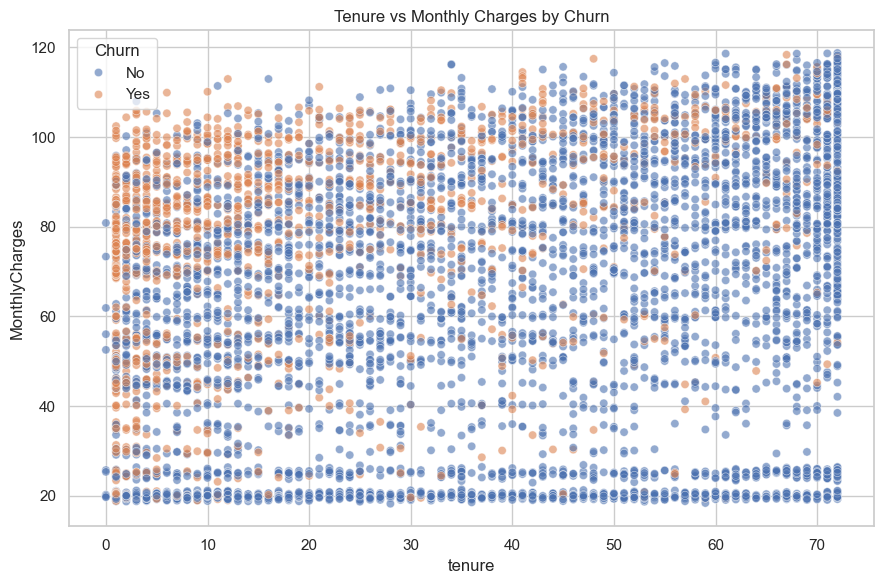

In [40]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", hue="Churn", alpha=0.6)
plt.title("Tenure vs Monthly Charges by Churn")
plt.tight_layout()
plt.show()


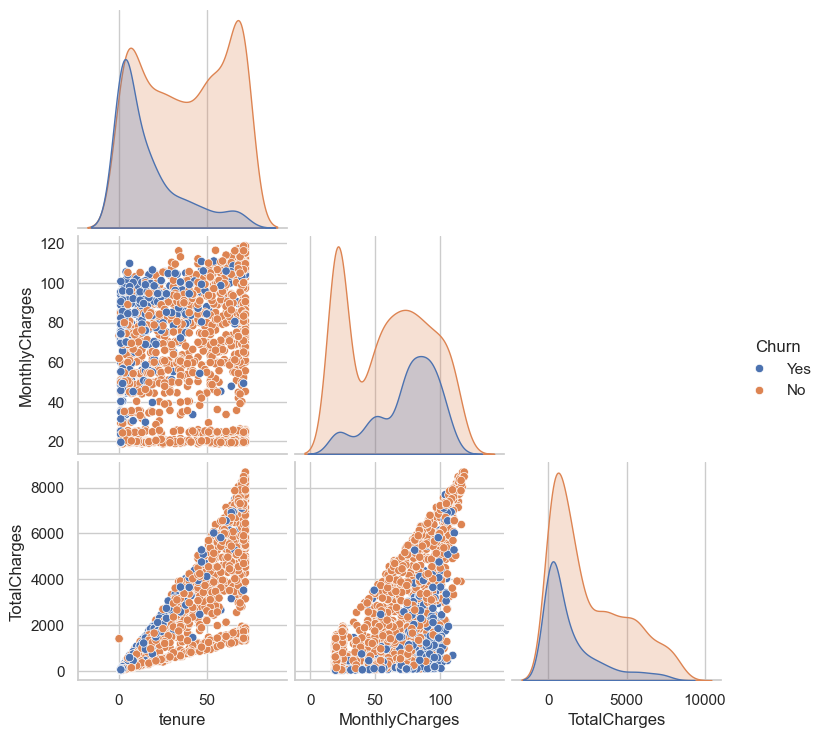

In [41]:
sample_df = df.sample(min(1500,len(df)), random_state=42)
sns.pairplot(sample_df[["tenure","MonthlyCharges","TotalCharges","Churn"]], hue="Churn", corner=True)
plt.show()


## 6. SQL Business Questions
The following 20 questions address customer size, churn, charges, tenure, contract, service and customer-profile patterns.


In [42]:
conn = sqlite3.connect(":memory:")
df.to_sql("customers", conn, index=False, if_exists="replace")
def run_sql(query):
    return pd.read_sql_query(query, conn)


### Q1 – Total Customers

In [43]:
run_sql('SELECT COUNT(*) AS total_customers FROM customers;')


,total_customers
0,7043


### Q2 – Churned Customers

In [44]:
run_sql("SELECT COUNT(*) AS churned_customers FROM customers WHERE Churn='Yes';")


,churned_customers
0,1869


### Q3 – Overall Churn Rate

In [45]:
run_sql('SELECT ROUND(100.0*AVG(ChurnFlag),2) AS churn_rate_pct FROM customers;')


,churn_rate_pct
0,26.54


### Q4 – Average Monthly Charge

In [46]:
run_sql('SELECT ROUND(AVG(MonthlyCharges),2) AS avg_monthly_charge FROM customers;')


,avg_monthly_charge
0,64.76


### Q5 – Average Tenure

In [47]:
run_sql('SELECT ROUND(AVG(tenure),2) AS avg_tenure_months FROM customers;')


,avg_tenure_months
0,32.37


### Q6 – Churn Rate by Contract

In [48]:
run_sql('SELECT Contract, COUNT(*) customers, ROUND(100.0*AVG(ChurnFlag),2) churn_rate_pct FROM customers GROUP BY Contract ORDER BY churn_rate_pct DESC;')


,Contract,customers,churn_rate_pct
0,Month-to-month,3875,42.71
1,One year,1473,11.27
2,Two year,1695,2.83


### Q7 – Churn Rate by Internet Service

In [49]:
run_sql('SELECT InternetService, COUNT(*) customers, ROUND(100.0*AVG(ChurnFlag),2) churn_rate_pct FROM customers GROUP BY InternetService ORDER BY churn_rate_pct DESC;')


,InternetService,customers,churn_rate_pct
0,Fiber optic,3096,41.89
1,DSL,2421,18.96
2,No,1526,7.40


### Q8 – Churn Rate by Payment Method

In [50]:
run_sql('SELECT PaymentMethod, COUNT(*) customers, ROUND(100.0*AVG(ChurnFlag),2) churn_rate_pct FROM customers GROUP BY PaymentMethod ORDER BY churn_rate_pct DESC;')


,PaymentMethod,customers,churn_rate_pct
0,Electronic check,2365,45.29
1,Mailed check,1612,19.11
2,Bank transfer (automatic),1544,16.71
3,Credit card (automatic),1522,15.24


### Q9 – Churn by Senior Citizen

In [51]:
run_sql('SELECT SeniorCitizenLabel, COUNT(*) customers, ROUND(100.0*AVG(ChurnFlag),2) churn_rate_pct FROM customers GROUP BY SeniorCitizenLabel ORDER BY churn_rate_pct DESC;')


,SeniorCitizenLabel,customers,churn_rate_pct
0,Yes,1142,41.68
1,No,5901,23.61


### Q10 – Churn by Partner

In [52]:
run_sql('SELECT Partner, COUNT(*) customers, ROUND(100.0*AVG(ChurnFlag),2) churn_rate_pct FROM customers GROUP BY Partner ORDER BY churn_rate_pct DESC;')


,Partner,customers,churn_rate_pct
0,No,3641,32.96
1,Yes,3402,19.66


### Q11 – Churn by Dependents

In [53]:
run_sql('SELECT Dependents, COUNT(*) customers, ROUND(100.0*AVG(ChurnFlag),2) churn_rate_pct FROM customers GROUP BY Dependents ORDER BY churn_rate_pct DESC;')


,Dependents,customers,churn_rate_pct
0,No,4933,31.28
1,Yes,2110,15.45


### Q12 – Monthly Charges by Churn

In [54]:
run_sql('SELECT Churn, ROUND(AVG(MonthlyCharges),2) avg_monthly_charge FROM customers GROUP BY Churn;')


,Churn,avg_monthly_charge
0,No,61.27
1,Yes,74.44


### Q13 – Tenure by Churn

In [55]:
run_sql('SELECT Churn, ROUND(AVG(tenure),2) avg_tenure FROM customers GROUP BY Churn;')


,Churn,avg_tenure
0,No,37.57
1,Yes,17.98


### Q14 – Revenue by Contract

In [56]:
run_sql('SELECT Contract, ROUND(SUM(TotalCharges),2) total_revenue FROM customers GROUP BY Contract ORDER BY total_revenue DESC;')


,Contract,total_revenue
0,Two year,6297228.45
1,Month-to-month,5305861.50
2,One year,4468450.97


### Q15 – Customers by Contract

In [57]:
run_sql('SELECT Contract, COUNT(*) customers FROM customers GROUP BY Contract ORDER BY customers DESC;')


,Contract,customers
0,Month-to-month,3875
1,Two year,1695
2,One year,1473


### Q16 – Customers by Internet Service

In [58]:
run_sql('SELECT InternetService, COUNT(*) customers FROM customers GROUP BY InternetService ORDER BY customers DESC;')


,InternetService,customers
0,Fiber optic,3096
1,DSL,2421
2,No,1526


### Q17 – Paperless Billing Usage

In [59]:
run_sql('SELECT PaperlessBilling, COUNT(*) customers, ROUND(100.0*COUNT(*)/(SELECT COUNT(*) FROM customers),2) percentage FROM customers GROUP BY PaperlessBilling;')


,PaperlessBilling,customers,percentage
0,No,2872,40.78
1,Yes,4171,59.22


### Q18 – Highest Average Monthly Charge Contract

In [60]:
run_sql('SELECT Contract, ROUND(AVG(MonthlyCharges),2) avg_monthly_charge FROM customers GROUP BY Contract ORDER BY avg_monthly_charge DESC LIMIT 1;')


,Contract,avg_monthly_charge
0,Month-to-month,66.4


### Q19 – Month-to-Month Churn

In [61]:
run_sql("SELECT ROUND(100.0*AVG(ChurnFlag),2) churn_rate_pct FROM customers WHERE Contract='Month-to-month';")


,churn_rate_pct
0,42.71


### Q20 – Long-Tenure Churn

In [62]:
run_sql('SELECT ROUND(100.0*AVG(ChurnFlag),2) churn_rate_pct FROM customers WHERE tenure>=12;')


,churn_rate_pct
0,17.49


## 7. Business Insights

Use the SQL outputs and charts above to document the strongest findings. Focus on:
- Contract type and churn risk
- Internet service and churn risk
- Payment method and churn risk
- Monthly charges and churn
- Tenure and retention
- Customer profile differences
- Revenue by contract type


## 8. Static Dashboard Mock-up

### KPI Cards
- Total Customers
- Churned Customers
- Churn Rate
- Average Monthly Charges
- Average Tenure

### Recommended Visuals
- Churn Rate by Contract
- Churn Rate by Internet Service
- Churn Rate by Payment Method
- Customer Distribution by Contract
- Monthly Charges by Churn
- Tenure Distribution
- Churn Distribution

### Recommended Slicers
Gender, Contract, Internet Service, Payment Method, Senior Citizen, Partner and Dependents.


## 9. Conclusion

Task 2 combines descriptive statistics, univariate and bivariate analysis, multivariate/correlation analysis, SQL business questions and dashboard planning. The findings provide the foundation for Task 3, where the key KPIs and deep-dive analysis will be implemented in an interactive Power BI dashboard.
